In [ ]:
#NLP
#Sentiment Analysis
!pip install vaderSentiment -q
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return pd.Series([compound, label])

reviews_clean[['vader_compound', 'vader_label']] = reviews_clean['Translated_Review'].apply(get_vader_sentiment)
print(reviews_clean[['Translated_Review', 'Sentiment', 'vader_label']].head(10))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.0 MB/s eta 0:00:00
                                   Translated_Review Sentiment vader_label
0  I like eat delicious food. That's I'm cooking ...  Positive    Positive
1    This help eating healthy exercise regular basis  Positive    Positive
2         Works great especially going grocery store  Positive    Positive
3                                       Best idea us  Positive    Positive
4                                           Best way  Positive    Positive
5                                            Amazing  Positive    Positive
6                               Looking forward app,   Neutral     Neutral
7              It helpful site ! It help foods get !   Neutral    Positive
8                                          good you.  Positive    Positive
9  Useful information The amount spelling errors ...  Positive    Positive


Agreement between VADER and original TextBlob labels: 76.3%


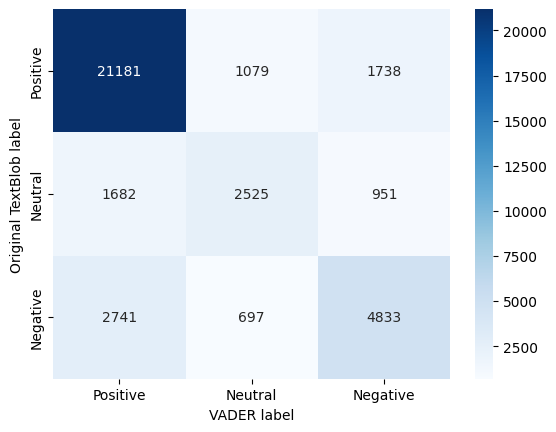

In [ ]:
agreement = (reviews_clean['Sentiment'] == reviews_clean['vader_label']).mean()
print(f"Agreement between VADER and original TextBlob labels: {agreement:.1%}")

from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(reviews_clean['Sentiment'], reviews_clean['vader_label'], labels=['Positive','Neutral','Negative'])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Positive','Neutral','Negative'], yticklabels=['Positive','Neutral','Negative'], cmap='Blues')
plt.xlabel('VADER label'); plt.ylabel('Original TextBlob label')
plt.show()

In [ ]:
from collections import Counter
import re

stopwords = set(['the','a','an','and','or','but','is','are','was','were','to','of','in','for',
                  'this','that','it','i','app','apps','on','with','not','my','have','has'])

def get_top_words(text_series, n=20):
    all_words = []
    for text in text_series.dropna():
        words = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
        all_words.extend([w for w in words if w not in stopwords])
    return Counter(all_words).most_common(n)

negative_reviews = reviews_clean[reviews_clean['vader_label'] == 'Negative']['Translated_Review']
positive_reviews = reviews_clean[reviews_clean['vader_label'] == 'Positive']['Translated_Review']

print("Top complaint words:", get_top_words(negative_reviews))
print("\nTop praise words:", get_top_words(positive_reviews))

Top complaint words: [('game', 1775), ('time', 1299), ('get', 1113), ('can', 1014), ('even', 911), ('update', 816), ('ads', 794), ('phone', 638), ('you', 592), ('like', 592), ('bad', 583), ('every', 571), ('work', 553), ('problem', 543), ('fix', 538), ('back', 503), ('really', 496), ('still', 493), ('many', 488), ('would', 487)]

Top praise words: [('game', 7349), ('like', 4841), ('good', 4813), ('great', 4594), ('love', 4541), ('get', 3325), ('time', 2975), ('would', 2817), ('really', 2509), ('easy', 2077), ('play', 2046), ('please', 1926), ('best', 1910), ('can', 1896), ('also', 1894), ('much', 1811), ('even', 1752), ('you', 1728), ('fun', 1692), ('ads', 1677)]


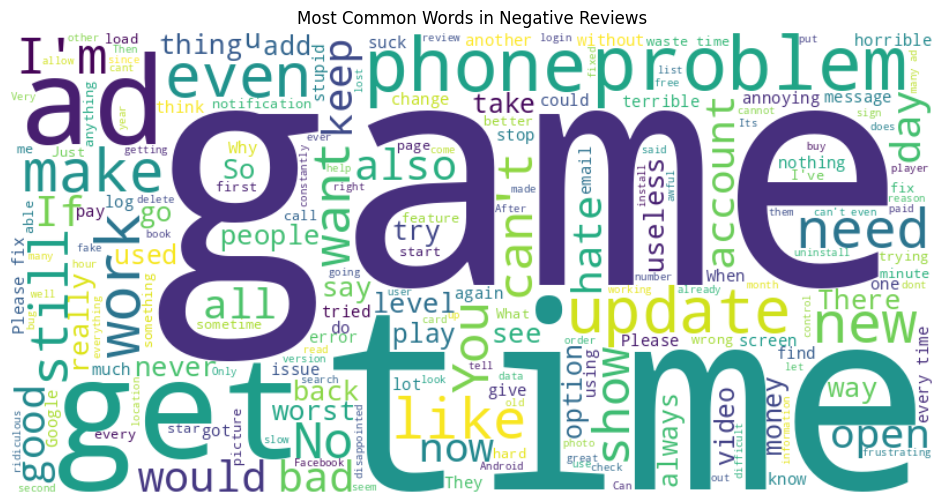

In [ ]:
!pip install wordcloud -q
from wordcloud import WordCloud

complaint_text = ' '.join(negative_reviews.dropna().astype(str))
wc = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(complaint_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews')
plt.show()

In [ ]:
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
client.load_table_from_dataframe(
    reviews_clean, f"{dataset_id}.reviews_with_sentiment", job_config=job_config
).result()
print("Sentiment table pushed to BigQuery")

Sentiment table pushed to BigQuery
